# Plant Disease Prediction

## Importing Dataset

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/new-plant-diseases-dataset


## Importing libraries

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image preprocessing

In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


#### To avoid Overshooting Loss function
1. Choose small learning rate default 0.001 here we have taken 0.0001
2. There may be chance of underfitting so increase number of neuron
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

### Building Convolution Layer

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

cnn = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1500, activation='relu'),
    Dropout(0.4),
    Dense(38, activation='softmax')
])

cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy'])


### Compiling and Training Phase

In [10]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     1,921,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,236,522 (16.16 MB)

 Trainable params: 1,978,538 (7.55 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 333s 147ms/step - accuracy: 0.3901 - loss: 2.2539 - val_accuracy: 0.6403 - val_loss: 1.2481
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 87s 40ms/step - accuracy: 0.6373 - loss: 1.2426 - val_accuracy: 0.6962 - val_loss: 1.0299
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 141s 40ms/step - accuracy: 0.6874 - loss: 1.0397 - val_accuracy: 0.7209 - val_loss: 0.9290
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 87s 40ms/step - accuracy: 0.7199 - loss: 0.9245 - val_accuracy: 0.7456 - val_loss: 0.8407
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.7433 - loss: 0.8401 - val_accuracy: 0.7528 - val_loss: 0.8140
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 90s 41ms/step - accuracy: 0.7597 - loss: 0.7850 - val_accuracy: 0.7667 - val_loss: 0.7663
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 136s 38ms/step - accuracy: 0.7722 - loss: 0.7329 - val_accuracy: 0.7752 - val_loss: 0.7384
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 143s 39ms/step - accuracy: 0.7

## Evaluating Model

In [12]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - accuracy: 0.8394 - loss: 0.5266
Training accuracy: 0.8412262797355652


In [13]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.7919 - loss: 0.6712
Validation accuracy: 0.7921124696731567


### Saving Model

In [14]:
cnn.save('trained_plant_disease_model.keras')

In [15]:
training_history.history #Return Dictionary of history

{'accuracy': [0.5013158917427063,
  0.6506721377372742,
  0.693989634513855,
  0.7236645817756653,
  0.7451170086860657,
  0.7606800198554993,
  0.7736823558807373,
  0.7837114930152893,
  0.795504629611969,
  0.8032719492912292],
 'loss': [1.7839765548706055,
  1.1892108917236328,
  1.0169579982757568,
  0.9113534092903137,
  0.8346282243728638,
  0.7790403366088867,
  0.7309907078742981,
  0.6949027180671692,
  0.6566413640975952,
  0.6279655694961548],
 'val_accuracy': [0.64028000831604,
  0.6961643695831299,
  0.720919668674469,
  0.7455611228942871,
  0.7527885437011719,
  0.7667311429977417,
  0.7752105593681335,
  0.7821534276008606,
  0.7886410355567932,
  0.7921124696731567],
 'val_loss': [1.24811851978302,
  1.029930830001831,
  0.9289801716804504,
  0.8406974673271179,
  0.8140126466751099,
  0.766261637210846,
  0.7384017109870911,
  0.7125962972640991,
  0.6873799562454224,
  0.6702408194541931]}

In [16]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [17]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Accuracy Visualization

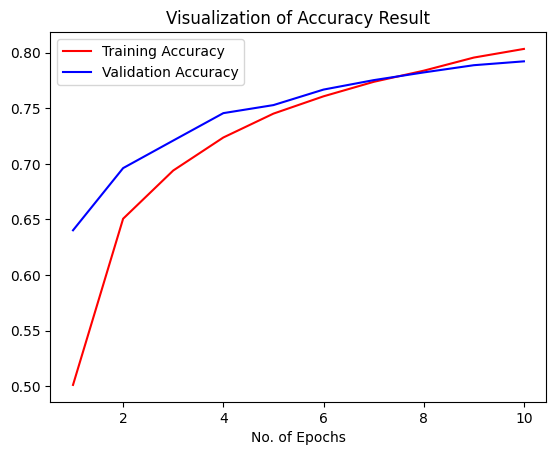

In [18]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Some other metrics for model evaluation

In [19]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [20]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [21]:
y_pred = cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

17572/17572 ━━━━━━━━━━━━━━━━━━━━ 106s 6ms/step


In [22]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [23]:
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [24]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [25]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [26]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.57      0.74      0.64       504
                                 Apple___Black_rot       0.85      0.86      0.85       497
                          Apple___Cedar_apple_rust       0.80      0.84      0.82       440
                                   Apple___healthy       0.64      0.78      0.70       502
                               Blueberry___healthy       0.79      0.78      0.78       454
          Cherry_(including_sour)___Powdery_mildew       0.77      0.81      0.79       421
                 Cherry_(including_sour)___healthy       0.91      0.95      0.92       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.79      0.74      0.76       410
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.82      0.86      0.

### Confusion Matrix Visualization

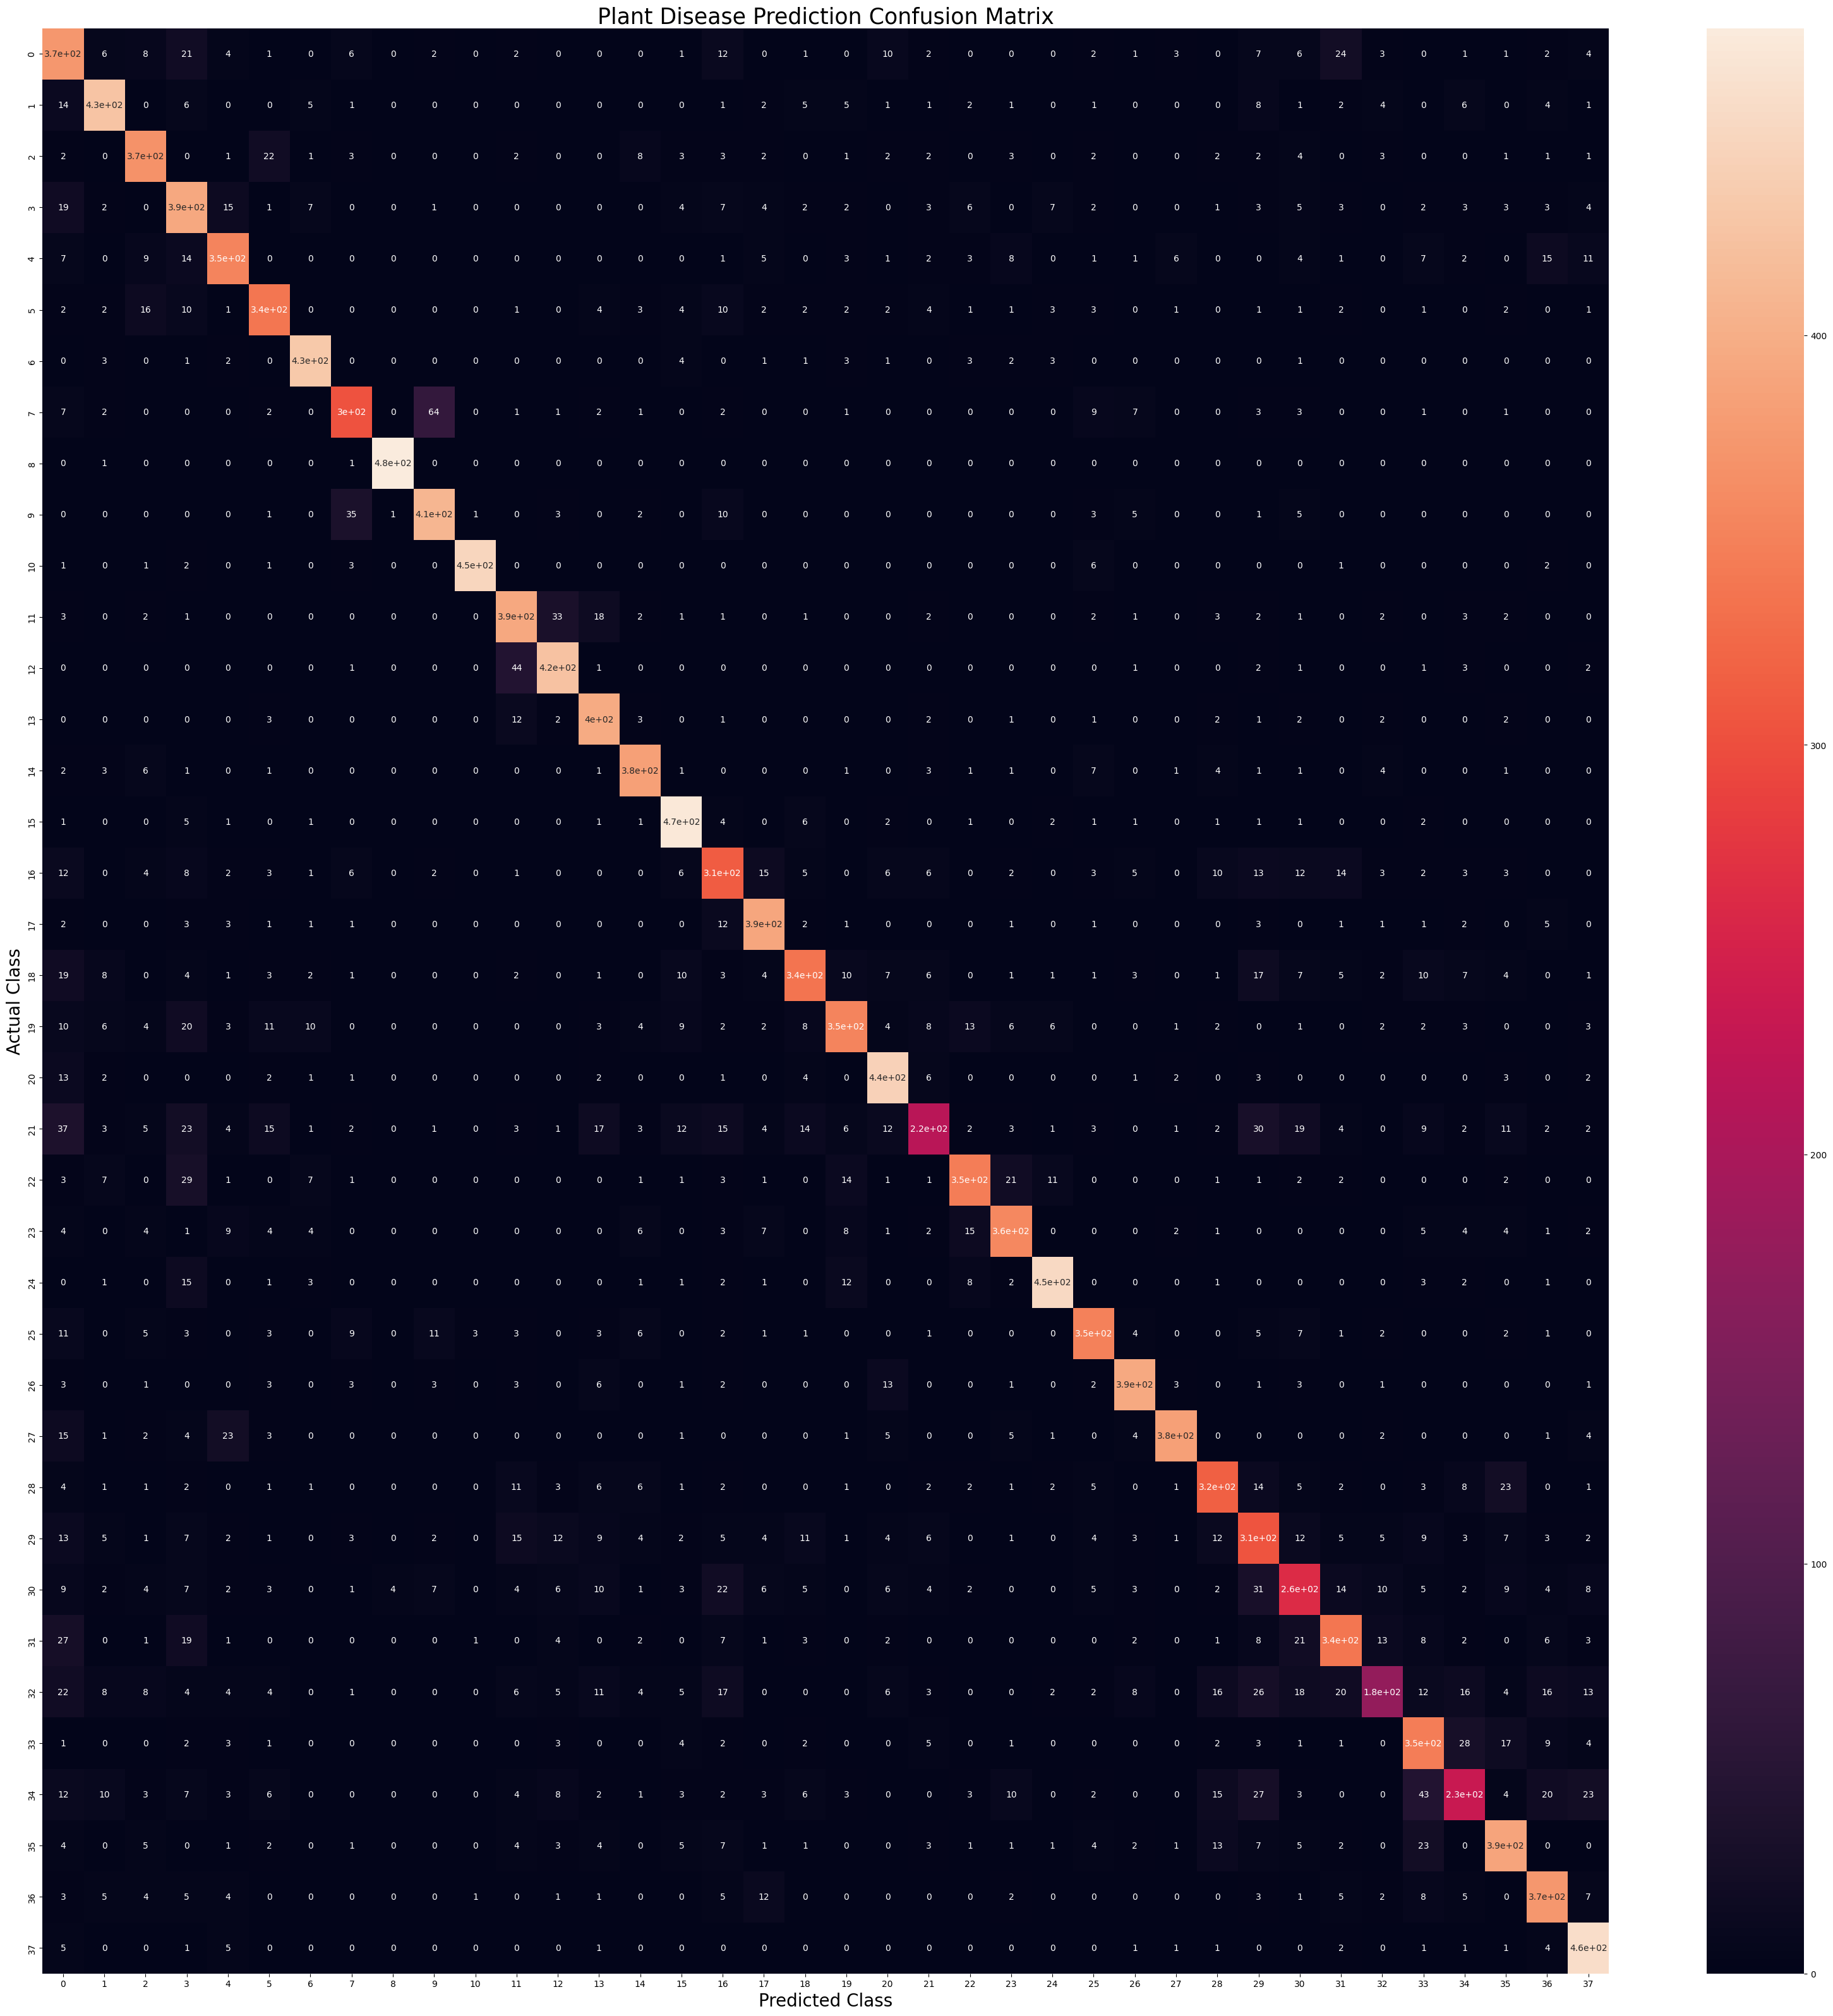

In [27]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()